In [0]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [0]:
# Load preprocessed data
print("=" * 60)
print("LOADING PREPROCESSED DATA")
print("=" * 60)

print("\nLoading training and test datasets...\n")

# Load Linear Regression data (one-hot encoded)
df_train_lr = spark.table("car_price_train_onehot").toPandas()
df_test_lr = spark.table("car_price_test_onehot").toPandas()

print(f"✓ Linear Regression data loaded:")
print(f"   Train: {df_train_lr.shape}")
print(f"   Test: {df_test_lr.shape}")

# Load Decision Tree/Random Forest data (derived features)
df_train_tree = spark.table("car_price_train_derived").toPandas()
df_test_tree = spark.table("car_price_test_derived").toPandas()

print(f"\n✓ Tree-based models data loaded:")
print(f"   Train: {df_train_tree.shape}")
print(f"   Test: {df_test_tree.shape}")

print("\nAll datasets loaded successfully!")

LOADING PREPROCESSED DATA

Loading training and test datasets...

✓ Linear Regression data loaded:
   Train: (164, 206)
   Test: (41, 206)

✓ Tree-based models data loaded:
   Train: (164, 31)
   Test: (41, 31)

All datasets loaded successfully!


In [0]:
# Prepare data for Linear Regression
print("=" * 60)
print("PREPARING DATA FOR LINEAR REGRESSION")
print("=" * 60)

# Separate features and target for Linear Regression
X_train_lr = df_train_lr.drop('price', axis=1)
y_train_lr = df_train_lr['price']

X_test_lr = df_test_lr.drop('price', axis=1)
y_test_lr = df_test_lr['price']

print(f"\nLinear Regression data prepared:")
print(f"   X_train: {X_train_lr.shape}")
print(f"   y_train: {y_train_lr.shape}")
print(f"   X_test: {X_test_lr.shape}")
print(f"   y_test: {y_test_lr.shape}")

# Prepare data for tree-based models
print("\n" + "=" * 60)
print("PREPARING DATA FOR TREE-BASED MODELS")
print("=" * 60)

# Separate features and target for tree models
X_train_tree = df_train_tree.drop('price', axis=1)
# Remove non-numeric columns
X_train_tree = X_train_tree.select_dtypes(include=[np.number])
y_train_tree = df_train_tree['price']

X_test_tree = df_test_tree.drop('price', axis=1)
X_test_tree = X_test_tree.select_dtypes(include=[np.number])
y_test_tree = df_test_tree['price']

print(f"\nTree-based models data prepared:")
print(f"   X_train: {X_train_tree.shape}")
print(f"   y_train: {y_train_tree.shape}")
print(f"   X_test: {X_test_tree.shape}")
print(f"   y_test: {y_test_tree.shape}")

print("\n✓ All data prepared!")

PREPARING DATA FOR LINEAR REGRESSION

Linear Regression data prepared:
   X_train: (164, 205)
   y_train: (164,)
   X_test: (41, 205)
   y_test: (41,)

PREPARING DATA FOR TREE-BASED MODELS

Tree-based models data prepared:
   X_train: (164, 30)
   y_train: (164,)
   X_test: (41, 30)
   y_test: (41,)

✓ All data prepared!


In [0]:
# Train Linear Regression Model
print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)

print("\nTraining Linear Regression model...\n")

# Initialize the model
lr_model = LinearRegression()

# Record training time
start_time = time.time()

# Train the model
lr_model.fit(X_train_lr, y_train_lr)

training_time_lr = time.time() - start_time

print(f"✓ Model trained successfully!")
print(f"   Training time: {training_time_lr:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
y_pred_train_lr = lr_model.predict(X_train_lr)
y_pred_test_lr = lr_model.predict(X_test_lr)

# Calculate metrics
print("\nEvaluating model performance...\n")

# Training metrics
train_mse_lr = mean_squared_error(y_train_lr, y_pred_train_lr)
train_rmse_lr = np.sqrt(train_mse_lr)
train_mae_lr = mean_absolute_error(y_train_lr, y_pred_train_lr)
train_r2_lr = r2_score(y_train_lr, y_pred_train_lr)

print("Training Set Performance:")
print(f"   RMSE: ${train_rmse_lr:,.2f}")
print(f"   MAE: ${train_mae_lr:,.2f}")
print(f"   R² Score: {train_r2_lr:.4f}")

# Test metrics
test_mse_lr = mean_squared_error(y_test_lr, y_pred_test_lr)
test_rmse_lr = np.sqrt(test_mse_lr)
test_mae_lr = mean_absolute_error(y_test_lr, y_pred_test_lr)
test_r2_lr = r2_score(y_test_lr, y_pred_test_lr)

print("\nTest Set Performance:")
print(f"   RMSE: ${test_rmse_lr:,.2f}")
print(f"   MAE: ${test_mae_lr:,.2f}")
print(f"   R² Score: {test_r2_lr:.4f}")

# Check for overfitting
print("\nOverfitting Check:")
print(f"   R² difference (train - test): {train_r2_lr - test_r2_lr:.4f}")
if train_r2_lr - test_r2_lr > 0.1:
    print("   ⚠️  Warning: Model may be overfitting")
else:
    print("   ✓ Model generalizes well")

print("\n" + "=" * 60)

MODEL 1: LINEAR REGRESSION

Training Linear Regression model...

✓ Model trained successfully!
   Training time: 0.78 seconds

Making predictions...

Evaluating model performance...

Training Set Performance:
   RMSE: $0.00
   MAE: $0.00
   R² Score: 1.0000

Test Set Performance:
   RMSE: $6,976.20
   MAE: $4,974.51
   R² Score: 0.3835

Overfitting Check:
   R² difference (train - test): 0.6165
   ⚠️  Warning: Model may be overfitting



Visualizing Linear Regression results...



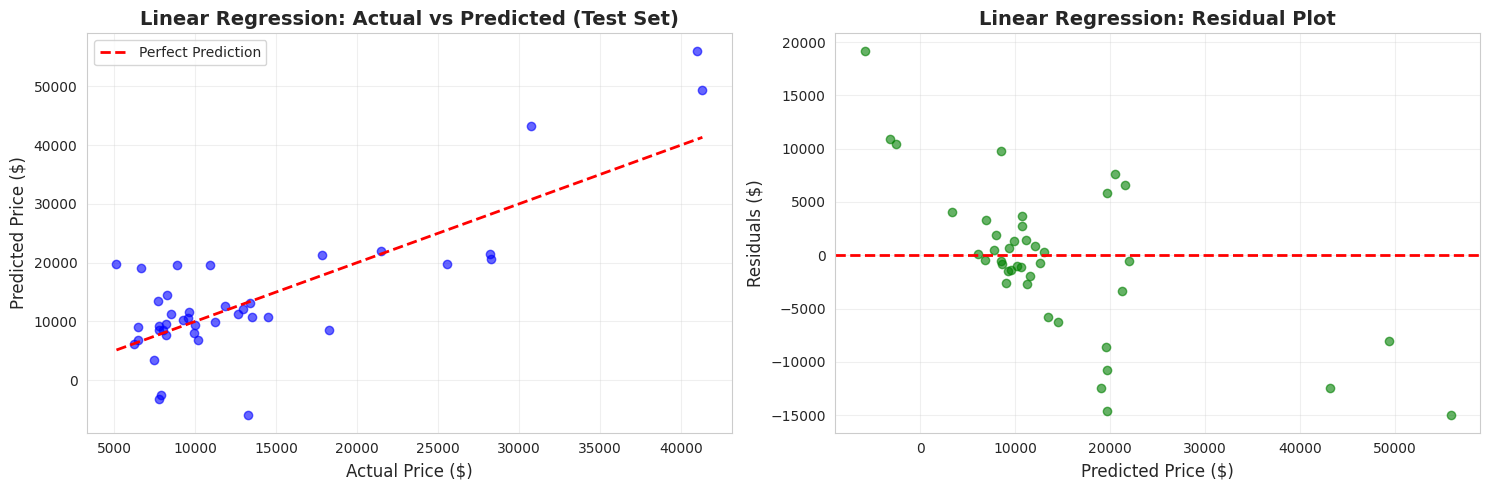

✓ Visualization complete!


In [0]:
# Visualize Linear Regression Results
print("Visualizing Linear Regression results...\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Actual vs Predicted (Test Set)
axes[0].scatter(y_test_lr, y_pred_test_lr, alpha=0.6, color='blue')
axes[0].plot([y_test_lr.min(), y_test_lr.max()], 
             [y_test_lr.min(), y_test_lr.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title('Linear Regression: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals_lr = y_test_lr - y_pred_test_lr
axes[1].scatter(y_pred_test_lr, residuals_lr, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Linear Regression: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
display(plt.show())

print("✓ Visualization complete!")

In [0]:
# Train Decision Tree Model
print("=" * 60)
print("MODEL 2: DECISION TREE")
print("=" * 60)

print("\nTraining Decision Tree model...\n")

# Initialize the model with hyperparameters
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Record training time
start_time = time.time()

# Train the model
dt_model.fit(X_train_tree, y_train_tree)

training_time_dt = time.time() - start_time

print(f"✓ Model trained successfully!")
print(f"   Training time: {training_time_dt:.2f} seconds")
print(f"   Tree depth: {dt_model.get_depth()}")
print(f"   Number of leaves: {dt_model.get_n_leaves()}")

# Make predictions
print("\nMaking predictions...")
y_pred_train_dt = dt_model.predict(X_train_tree)
y_pred_test_dt = dt_model.predict(X_test_tree)

# Calculate metrics
print("\nEvaluating model performance...\n")

# Training metrics
train_mse_dt = mean_squared_error(y_train_tree, y_pred_train_dt)
train_rmse_dt = np.sqrt(train_mse_dt)
train_mae_dt = mean_absolute_error(y_train_tree, y_pred_train_dt)
train_r2_dt = r2_score(y_train_tree, y_pred_train_dt)

print("Training Set Performance:")
print(f"   RMSE: ${train_rmse_dt:,.2f}")
print(f"   MAE: ${train_mae_dt:,.2f}")
print(f"   R² Score: {train_r2_dt:.4f}")

# Test metrics
test_mse_dt = mean_squared_error(y_test_tree, y_pred_test_dt)
test_rmse_dt = np.sqrt(test_mse_dt)
test_mae_dt = mean_absolute_error(y_test_tree, y_pred_test_dt)
test_r2_dt = r2_score(y_test_tree, y_pred_test_dt)

print("\nTest Set Performance:")
print(f"   RMSE: ${test_rmse_dt:,.2f}")
print(f"   MAE: ${test_mae_dt:,.2f}")
print(f"   R² Score: {test_r2_dt:.4f}")

# Check for overfitting
print("\nOverfitting Check:")
print(f"   R² difference (train - test): {train_r2_dt - test_r2_dt:.4f}")
if train_r2_dt - test_r2_dt > 0.1:
    print("   ⚠️  Warning: Model may be overfitting")
else:
    print("   ✓ Model generalizes well")

print("\n" + "=" * 60)

MODEL 2: DECISION TREE

Training Decision Tree model...

✓ Model trained successfully!
   Training time: 0.03 seconds
   Tree depth: 7
   Number of leaves: 25

Making predictions...

Evaluating model performance...

Training Set Performance:
   RMSE: $1,302.28
   MAE: $795.44
   R² Score: 0.9716

Test Set Performance:
   RMSE: $2,605.99
   MAE: $1,676.12
   R² Score: 0.9140

Overfitting Check:
   R² difference (train - test): 0.0576
   ✓ Model generalizes well



Visualizing Decision Tree results...



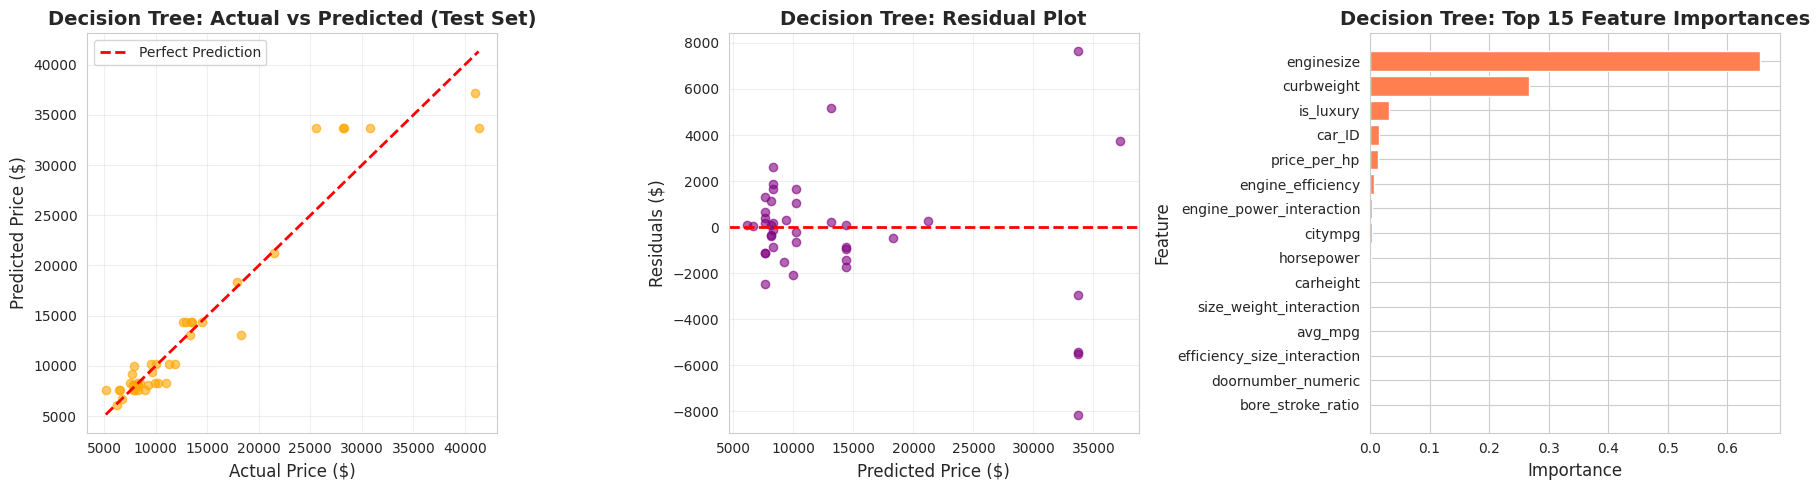

✓ Visualization complete!


In [0]:
# Visualize Decision Tree Results
print("Visualizing Decision Tree results...\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted (Test Set)
axes[0].scatter(y_test_tree, y_pred_test_dt, alpha=0.6, color='orange')
axes[0].plot([y_test_tree.min(), y_test_tree.max()], 
             [y_test_tree.min(), y_test_tree.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title('Decision Tree: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals_dt = y_test_tree - y_pred_test_dt
axes[1].scatter(y_pred_test_dt, residuals_dt, alpha=0.6, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Decision Tree: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
feature_importance_dt = pd.DataFrame({
    'feature': X_train_tree.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[2].barh(feature_importance_dt['feature'], feature_importance_dt['importance'], color='coral')
axes[2].set_xlabel('Importance', fontsize=12)
axes[2].set_ylabel('Feature', fontsize=12)
axes[2].set_title('Decision Tree: Top 15 Feature Importances', fontsize=14, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
display(plt.show())

print("✓ Visualization complete!")

In [0]:
# Train Random Forest Model
print("=" * 60)
print("MODEL 3: RANDOM FOREST")
print("=" * 60)

print("\nTraining Random Forest model...\n")

# Initialize the model with hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Record training time
start_time = time.time()

# Train the model
rf_model.fit(X_train_tree, y_train_tree)

training_time_rf = time.time() - start_time

print(f"✓ Model trained successfully!")
print(f"   Training time: {training_time_rf:.2f} seconds")
print(f"   Number of trees: {rf_model.n_estimators}")
print(f"   Number of features used: {rf_model.n_features_in_}")

# Make predictions
print("\nMaking predictions...")
y_pred_train_rf = rf_model.predict(X_train_tree)
y_pred_test_rf = rf_model.predict(X_test_tree)

# Calculate metrics
print("\nEvaluating model performance...\n")

# Training metrics
train_mse_rf = mean_squared_error(y_train_tree, y_pred_train_rf)
train_rmse_rf = np.sqrt(train_mse_rf)
train_mae_rf = mean_absolute_error(y_train_tree, y_pred_train_rf)
train_r2_rf = r2_score(y_train_tree, y_pred_train_rf)

print("Training Set Performance:")
print(f"   RMSE: ${train_rmse_rf:,.2f}")
print(f"   MAE: ${train_mae_rf:,.2f}")
print(f"   R² Score: {train_r2_rf:.4f}")

# Test metrics
test_mse_rf = mean_squared_error(y_test_tree, y_pred_test_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
test_mae_rf = mean_absolute_error(y_test_tree, y_pred_test_rf)
test_r2_rf = r2_score(y_test_tree, y_pred_test_rf)

print("\nTest Set Performance:")
print(f"   RMSE: ${test_rmse_rf:,.2f}")
print(f"   MAE: ${test_mae_rf:,.2f}")
print(f"   R² Score: {test_r2_rf:.4f}")

# Check for overfitting
print("\nOverfitting Check:")
print(f"   R² difference (train - test): {train_r2_rf - test_r2_rf:.4f}")
if train_r2_rf - test_r2_rf > 0.1:
    print("   ⚠️  Warning: Model may be overfitting")
else:
    print("   ✓ Model generalizes well")

print("\n" + "=" * 60)

MODEL 3: RANDOM FOREST

Training Random Forest model...

✓ Model trained successfully!
   Training time: 0.35 seconds
   Number of trees: 100
   Number of features used: 30

Making predictions...

Evaluating model performance...

Training Set Performance:
   RMSE: $1,325.03
   MAE: $786.44
   R² Score: 0.9706

Test Set Performance:
   RMSE: $1,851.37
   MAE: $1,205.14
   R² Score: 0.9566

Overfitting Check:
   R² difference (train - test): 0.0140
   ✓ Model generalizes well



Visualizing Random Forest results...



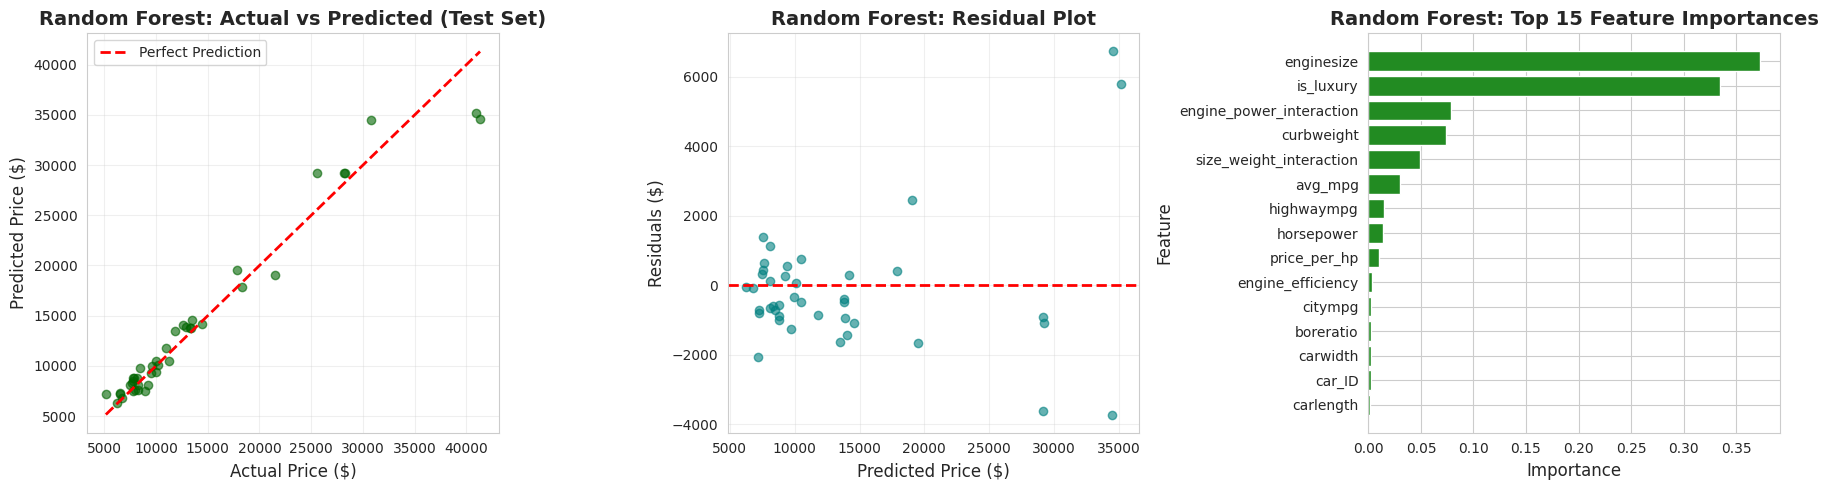

✓ Visualization complete!


In [0]:
# Visualize Random Forest Results
print("Visualizing Random Forest results...\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted (Test Set)
axes[0].scatter(y_test_tree, y_pred_test_rf, alpha=0.6, color='darkgreen')
axes[0].plot([y_test_tree.min(), y_test_tree.max()], 
             [y_test_tree.min(), y_test_tree.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title('Random Forest: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals_rf = y_test_tree - y_pred_test_rf
axes[1].scatter(y_pred_test_rf, residuals_rf, alpha=0.6, color='teal')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Random Forest: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train_tree.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[2].barh(feature_importance_rf['feature'], feature_importance_rf['importance'], color='forestgreen')
axes[2].set_xlabel('Importance', fontsize=12)
axes[2].set_ylabel('Feature', fontsize=12)
axes[2].set_title('Random Forest: Top 15 Feature Importances', fontsize=14, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
display(plt.show())

print("✓ Visualization complete!")

In [0]:
# Compare All Models
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train RMSE': [train_rmse_lr, train_rmse_dt, train_rmse_rf],
    'Test RMSE': [test_rmse_lr, test_rmse_dt, test_rmse_rf],
    'Train MAE': [train_mae_lr, train_mae_dt, train_mae_rf],
    'Test MAE': [test_mae_lr, test_mae_dt, test_mae_rf],
    'Train R²': [train_r2_lr, train_r2_dt, train_r2_rf],
    'Test R²': [test_r2_lr, test_r2_dt, test_r2_rf],
    'Training Time (s)': [training_time_lr, training_time_dt, training_time_rf]
})

print("\nPerformance Metrics Comparison:\n")
display(model_comparison)

# Identify best model
best_model_idx = model_comparison['Test R²'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_r2 = model_comparison.loc[best_model_idx, 'Test R²']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test R² Score: {best_r2:.4f}")
print(f"   Test RMSE: ${model_comparison.loc[best_model_idx, 'Test RMSE']:,.2f}")
print(f"   Test MAE: ${model_comparison.loc[best_model_idx, 'Test MAE']:,.2f}")

MODEL COMPARISON

Performance Metrics Comparison:



Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²,Training Time (s)
Linear Regression,2.028110437679199E-6,6976.2026310064175,1.5673168690693452E-6,4974.514970533435,1.0,0.38352008668206183,0.780266523361206
Decision Tree,1302.2758635659302,2605.9897001305744,795.4371515679443,1676.1206122725512,0.9715629791561765,0.9139747096548436,0.03078627586364746
Random Forest,1325.0347180755168,1851.3716226710446,786.4392529750214,1205.1366739017951,0.9705603509271874,0.9565821851099197,0.353168249130249



🏆 BEST MODEL: Random Forest
   Test R² Score: 0.9566
   Test RMSE: $1,851.37
   Test MAE: $1,205.14



Visualizing model comparison...



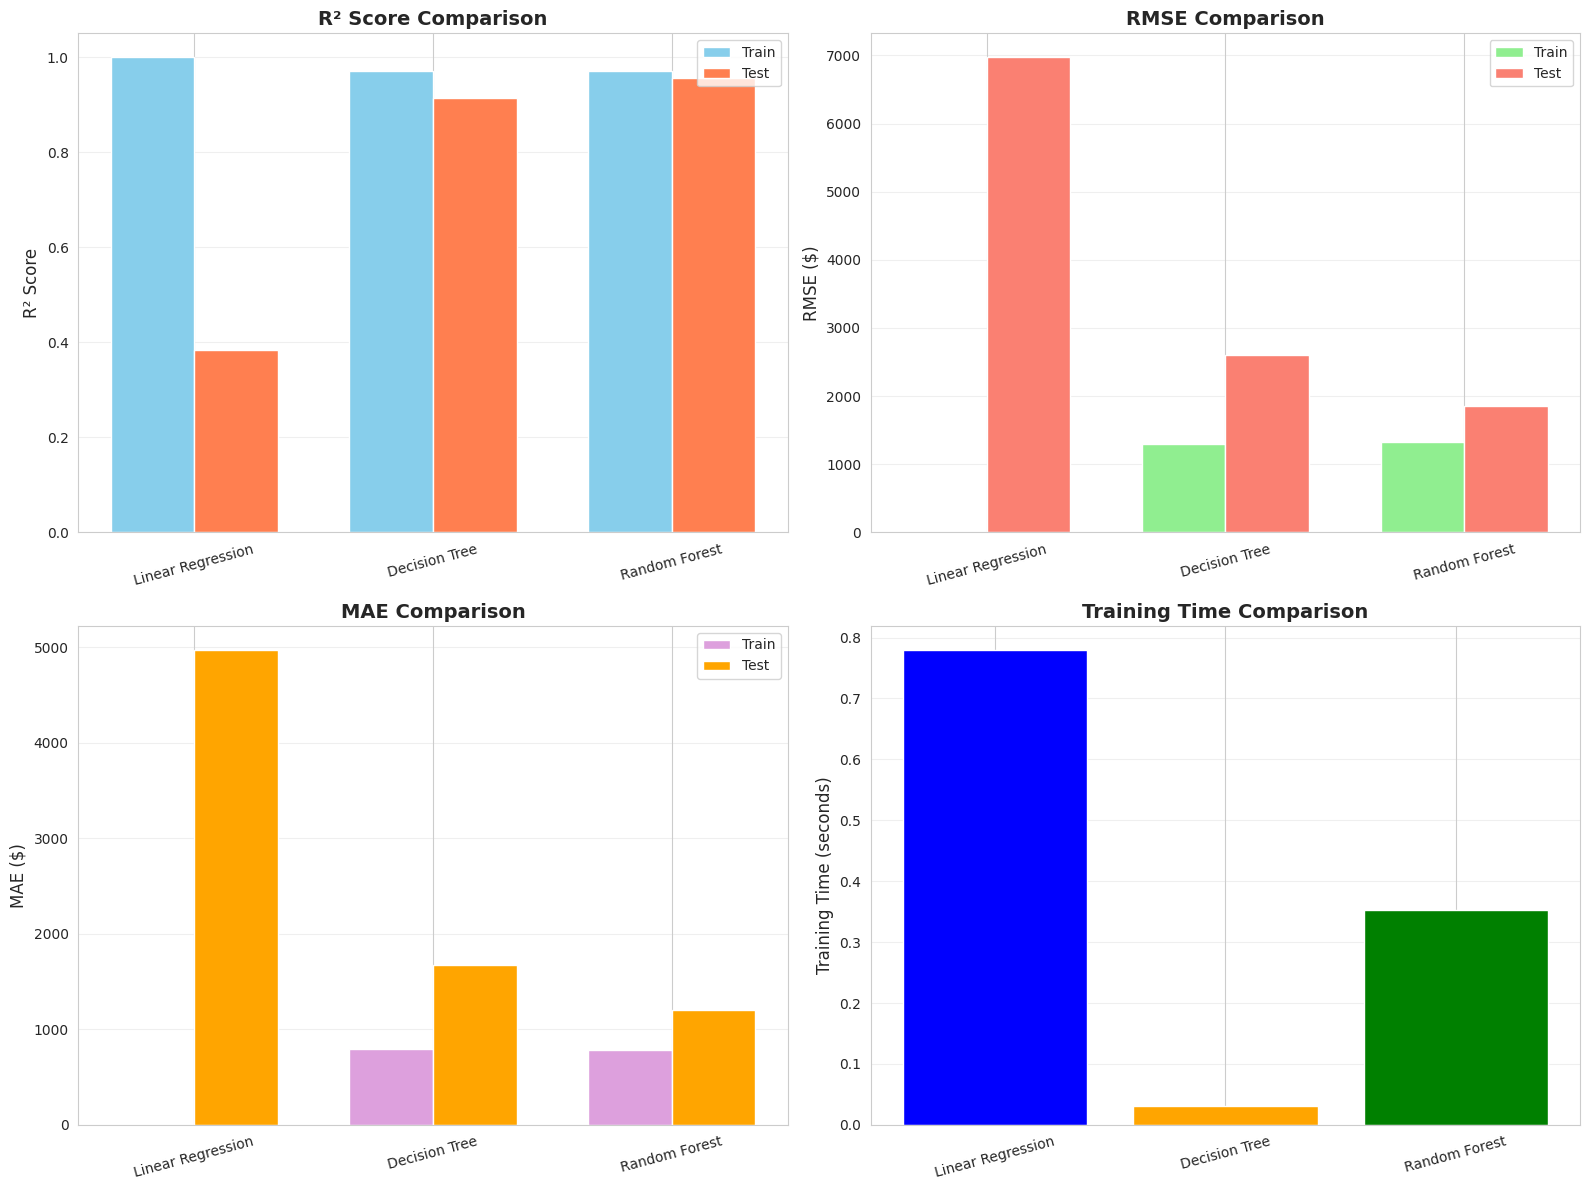

✓ Comparison visualization complete!


In [0]:
# Visualize Model Comparison
print("\nVisualizing model comparison...\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: R² Score Comparison
models = model_comparison['Model']
x_pos = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x_pos - width/2, model_comparison['Train R²'], width, label='Train', color='skyblue')
axes[0, 0].bar(x_pos + width/2, model_comparison['Test R²'], width, label='Test', color='coral')
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=15)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: RMSE Comparison
axes[0, 1].bar(x_pos - width/2, model_comparison['Train RMSE'], width, label='Train', color='lightgreen')
axes[0, 1].bar(x_pos + width/2, model_comparison['Test RMSE'], width, label='Test', color='salmon')
axes[0, 1].set_ylabel('RMSE ($)', fontsize=12)
axes[0, 1].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models, rotation=15)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: MAE Comparison
axes[1, 0].bar(x_pos - width/2, model_comparison['Train MAE'], width, label='Train', color='plum')
axes[1, 0].bar(x_pos + width/2, model_comparison['Test MAE'], width, label='Test', color='orange')
axes[1, 0].set_ylabel('MAE ($)', fontsize=12)
axes[1, 0].set_title('MAE Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models, rotation=15)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Training Time Comparison
axes[1, 1].bar(models, model_comparison['Training Time (s)'], color=['blue', 'orange', 'green'])
axes[1, 1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1, 1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(models, rotation=15)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
display(plt.show())

print("✓ Comparison visualization complete!")

In [0]:
# Model Training Summary
print("=" * 60)
print("MODEL TRAINING SUMMARY")
print("=" * 60)

print("\n📊 MODELS TRAINED:\n")

print("1. LINEAR REGRESSION")
print(f"   - Algorithm: Ordinary Least Squares")
print(f"   - Features: {X_train_lr.shape[1]} (one-hot encoded)")
print(f"   - Test R²: {test_r2_lr:.4f}")
print(f"   - Test RMSE: ${test_rmse_lr:,.2f}")
print(f"   - Training time: {training_time_lr:.2f}s")

print("\n2. DECISION TREE")
print(f"   - Max depth: 10")
print(f"   - Features: {X_train_tree.shape[1]} (derived features)")
print(f"   - Test R²: {test_r2_dt:.4f}")
print(f"   - Test RMSE: ${test_rmse_dt:,.2f}")
print(f"   - Training time: {training_time_dt:.2f}s")

print("\n3. RANDOM FOREST")
print(f"   - Number of trees: 100")
print(f"   - Max depth: 15")
print(f"   - Features: {X_train_tree.shape[1]} (derived features)")
print(f"   - Test R²: {test_r2_rf:.4f}")
print(f"   - Test RMSE: ${test_rmse_rf:,.2f}")
print(f"   - Training time: {training_time_rf:.2f}s")

print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"   - Best Test R²: {best_r2:.4f}")
print(f"   - Explains {best_r2*100:.2f}% of price variance")

print("\n📈 KEY INSIGHTS:")

# R² comparison
r2_scores = model_comparison['Test R²'].values
if r2_scores[2] > r2_scores[1] > r2_scores[0]:
    print("   ✓ Ensemble method (Random Forest) outperforms single tree")
if max(r2_scores) - min(r2_scores) > 0.1:
    print("   ✓ Significant performance difference between models")
else:
    print("   • Models perform similarly")

# Overfitting check
overfit_scores = [
    train_r2_lr - test_r2_lr,
    train_r2_dt - test_r2_dt,
    train_r2_rf - test_r2_rf
]
if all(score < 0.1 for score in overfit_scores):
    print("   ✓ All models generalize well (no overfitting)")

print("\n🎯 RECOMMENDATIONS:")
if best_model_name == 'Random Forest':
    print("   • Use Random Forest for production predictions")
    print("   • Consider hyperparameter tuning to improve further")
    print("   • Ensemble methods handle non-linear relationships well")
elif best_model_name == 'Decision Tree':
    print("   • Decision Tree offers good interpretability")
    print("   • Consider Random Forest for better generalization")
else:
    print("   • Linear Regression is simplest and fastest")
    print("   • Consider feature engineering or polynomial features")

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)

MODEL TRAINING SUMMARY

📊 MODELS TRAINED:

1. LINEAR REGRESSION
   - Algorithm: Ordinary Least Squares
   - Features: 205 (one-hot encoded)
   - Test R²: 0.3835
   - Test RMSE: $6,976.20
   - Training time: 0.78s

2. DECISION TREE
   - Max depth: 10
   - Features: 30 (derived features)
   - Test R²: 0.9140
   - Test RMSE: $2,605.99
   - Training time: 0.03s

3. RANDOM FOREST
   - Number of trees: 100
   - Max depth: 15
   - Features: 30 (derived features)
   - Test R²: 0.9566
   - Test RMSE: $1,851.37
   - Training time: 0.35s

🏆 BEST PERFORMING MODEL: Random Forest
   - Best Test R²: 0.9566
   - Explains 95.66% of price variance

📈 KEY INSIGHTS:
   ✓ Ensemble method (Random Forest) outperforms single tree
   ✓ Significant performance difference between models

🎯 RECOMMENDATIONS:
   • Use Random Forest for production predictions
   • Consider hyperparameter tuning to improve further
   • Ensemble methods handle non-linear relationships well

TRAINING COMPLETE!
